# Import and Configuration

In [1]:
# === Dependencies ===
import os
import math
import numpy as np
import pandas as pd
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModel
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_fscore_support, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
# === Config ===
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
LR = 3e-5
ASPECT_COLS = [
    'Clean','Comfort','Facilities/Amenities','Location','Bar','Bed',
    'Parking','Noise','Reception-checkin','Lift','Value for money',
    'Wi-Fi','Generic'
]
NUM_ASPECTS = len(ASPECT_COLS)
NUM_SENT_CLASSES = 3   # 0=neg,1=neutral,2=pos
RANDOM_STATE = 42

# Load data and Preprocessing

In [3]:
# === Load data ===
from google.colab import drive
drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/ProjectData/HRAST.csv'
df = pd.read_csv(data_path)
# df = pd.read_csv("HRAST.csv")
print(df.head())

Mounted at /content/drive
   id                                             review Unnamed: 2  positive  \
0   1                            1 elevator not working.        NaN         0   
1   2     1 euros to park per day on their own premises.        NaN         0   
2   3                          1 hour queue to check-in.        NaN         0   
3   4  1 min walk to metro entrance and also few min ...        NaN         1   
4   5  1 minute walk from the main metro & train stat...        NaN         1   

   negative  neutral  Clean  Comfort  Facilities/Amenities  Location  ...  \
0         1        0      0        0                     0         0  ...   
1         0        1      0        0                     0         0  ...   
2         1        0      0        0                     0         0  ...   
3         0        0      0        0                     0         1  ...   
4         0        0      0        0                     0         1  ...   

   Bar  Bed  Parking  No

In [4]:
df.drop(columns=['Unnamed: 2', 'id'], inplace=True)

In [5]:
df['Location'] = df['Location'].astype(int)

In [6]:
#Text Cleaning
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # remove HTML
    text = re.sub(r'[^a-z0-9\s]', ' ', text)   # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df['clean_review'] = df['review'].apply(clean_text)
df['clean_review']

,clean_review
0,1 elevator not working
1,1 euros to park per day on their own premises
2,1 hour queue to check in
3,1 min walk to metro entrance and also few min ...
4,1 minute walk from the main metro train statio...
...,...
23108,young staff that deserves success
23109,young clean a stone s throw from the city center
23110,young friendly and helpful staff
23111,young very friendly and attentive staff at rec...


In [7]:
df['sentiment_label'] = df[['negative','neutral','positive']].idxmax(axis=1)
map_sent = {'negative':0, 'neutral':1, 'positive':2}
df['sentiment'] = df['sentiment_label'].map(map_sent).astype(int)

# All data for aspect detection
all_df = df.copy()

# Count number of aspects per row
df['num_aspects'] = df[ASPECT_COLS].sum(axis=1)

# Single-aspect rows only for aspect-conditioned sentiment training
single_df = df[df['num_aspects'] == 1].copy()
single_df = single_df.reset_index(drop=True)

print("Total:", len(all_df), "Single-aspect:", len(single_df))

Total: 23113 Single-aspect: 12464


In [ ]:
# Show distribution of which aspect is active
aspect_distribution = single_df[ASPECT_COLS].sum().sort_values(ascending=False)
print("\nSingle-aspect distribution:")
print(aspect_distribution)



Single-aspect distribution:
Location                3314
Facilities/Amenities    2037
Clean                   1535
Generic                 1098
Noise                   1011
Comfort                  968
Reception-checkin        726
Value for money          467
Bed                      411
Parking                  324
Bar                      197
Wi-Fi                    192
Lift                     184
dtype: int64


/tmp/ipykernel_3549843/2671111209.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=aspect_distribution.index, y=aspect_distribution.values, palette="viridis")


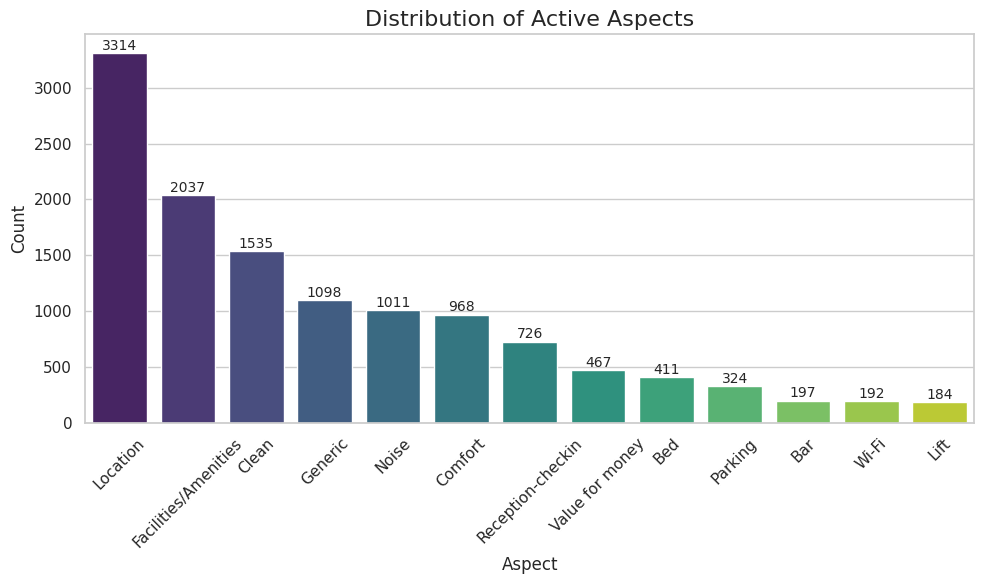

In [ ]:

# Set style for seaborn
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
barplot = sns.barplot(x=aspect_distribution.index, y=aspect_distribution.values, palette="viridis")

# Add numbers on top of each bar
for i, value in enumerate(aspect_distribution.values):
    barplot.text(i, value + 0.5, str(value), ha='center', va='bottom', fontsize=10)

plt.title("Distribution of Active Aspects", fontsize=16)
plt.xlabel("Aspect", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
# Show distribution of aspect in all df
aspect_distribution_all = df[ASPECT_COLS].sum().sort_values(ascending=False)
print("\nMulti-aspect distribution:")
print(aspect_distribution_all)


Multi-aspect distribution:
Location                4729
Clean                   2927
Facilities/Amenities    2923
Comfort                 2562
Generic                 1973
Noise                   1604
Bed                     1480
Reception-checkin        953
Value for money          892
Parking                  541
Bar                      322
Lift                     291
Wi-Fi                    268
dtype: int64


/tmp/ipython-input-2179682696.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=aspect_distribution_all.index, y=aspect_distribution_all.values, palette="viridis")


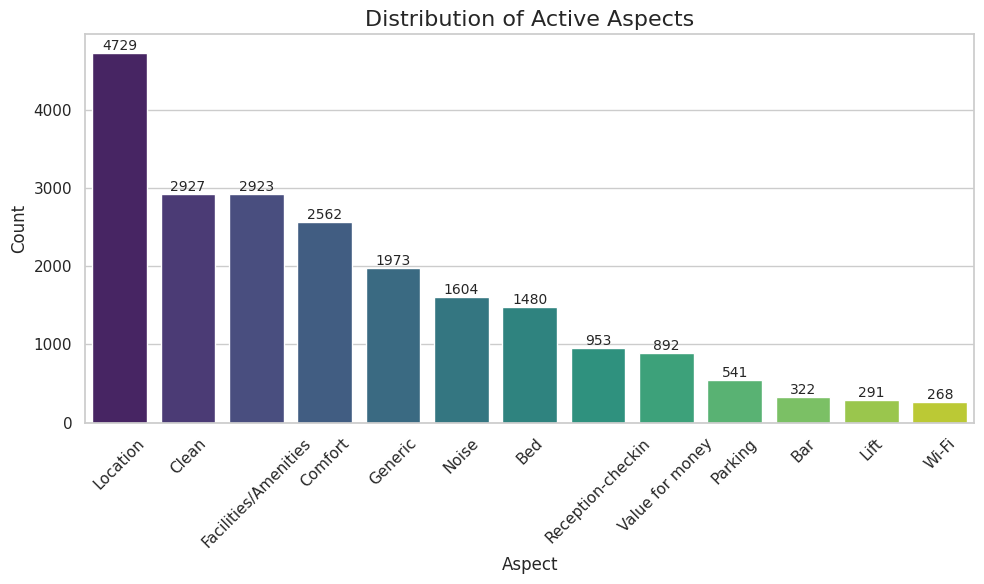

In [11]:

# Set style for seaborn
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
barplot = sns.barplot(x=aspect_distribution_all.index, y=aspect_distribution_all.values, palette="viridis")

# Add numbers on top of each bar
for i, value in enumerate(aspect_distribution_all.values):
     barplot.text(i, value + 0.5, str(value), ha='center', va='bottom', fontsize=10)

plt.title("Distribution of Active Aspects", fontsize=16)
plt.xlabel("Aspect", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
# -------- SPLITS (text-level) --------
# For aspect (multi-label) use all_df
texts_all = all_df['clean_review'].tolist()
y_aspect_all = all_df[ASPECT_COLS].values.astype(np.float32)    # shape (N, NUM_ASPECTS)

X_train_all, X_temp_all, y_aspect_train, y_aspect_temp = train_test_split(
    texts_all, y_aspect_all, test_size=0.3, random_state=RANDOM_STATE, shuffle=True
)
X_val_all, X_test_all, y_aspect_val, y_aspect_test = train_test_split(
    X_temp_all, y_aspect_temp, test_size=0.5, random_state=RANDOM_STATE, shuffle=True
)


In [13]:
# --- Split single-aspect data (aspect-conditioned sentiment) ---


# For sentiment (single-aspect rows only)
texts_single = single_df['clean_review'].tolist()
# compute aspect idx (0..NUM_ASPECTS-1) for each single-aspect sentence
single_aspect_idx = single_df.apply(lambda r: ASPECT_COLS.index(r[ASPECT_COLS].idxmax()), axis=1).values.astype(np.int32)
y_sent_single = single_df['sentiment'].values.astype(np.int32)

X_train_single, X_temp_single, y_aspect_idx_train, y_aspect_idx_temp, y_sent_train, y_sent_temp = train_test_split(
    texts_single, single_aspect_idx, y_sent_single, test_size=0.3, random_state=RANDOM_STATE, shuffle=True
)
X_val_single, X_test_single, y_aspect_idx_val, y_aspect_idx_test, y_sent_val, y_sent_test = train_test_split(
    X_temp_single, y_aspect_idx_temp, y_sent_temp, test_size=0.5, random_state=RANDOM_STATE, shuffle=True
)



In [14]:
# === Tokenizer and encoder ===
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts, max_len=MAX_LEN):
    return tokenizer(
        texts.tolist() if isinstance(texts, pd.Series) else texts,
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='tf'
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [15]:
enc_train_all = tokenize(X_train_all)
enc_val_all   = tokenize(X_val_all)
enc_test_all  = tokenize(X_test_all)


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


In [16]:
enc_train_single = tokenize(X_train_single)
enc_val_single   = tokenize(X_val_single)
enc_test_single  = tokenize(X_test_single)

In [17]:
# -------- TF.DATA creation (re-usable) --------
def make_aspect_dataset(encodings, labels, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        {'input_ids': encodings['input_ids'], 'attention_mask': encodings['attention_mask']},
        labels
    ))
    if shuffle:
        ds = ds.shuffle(2048, seed=RANDOM_STATE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def make_sent_dataset(encodings, aspect_idx, sent_labels, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((
        {
            'input_ids': encodings['input_ids'],
            'attention_mask': encodings['attention_mask'],
            'aspect_idx': aspect_idx
        },
        sent_labels
    ))
    if shuffle:
        ds = ds.shuffle(2048, seed=RANDOM_STATE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [18]:
ds_train_all = make_aspect_dataset(enc_train_all, y_aspect_train, shuffle=True)
ds_val_all   = make_aspect_dataset(enc_val_all, y_aspect_val, shuffle=False)
ds_test_all  = make_aspect_dataset(enc_test_all, y_aspect_test, shuffle=False)




In [19]:
ds_train_sent = make_sent_dataset(enc_train_single, y_aspect_idx_train, y_sent_train, shuffle=True)
ds_val_sent   = make_sent_dataset(enc_val_single,   y_aspect_idx_val,   y_sent_val, shuffle=False)
ds_test_sent  = make_sent_dataset(enc_test_single,  y_aspect_idx_test,  y_sent_test, shuffle=False)

##  Compute class weights / pos weights

In [20]:
# Aspect pos_weight: (neg_count / pos_count) per aspect to upweight positives
aspect_pos_counts = all_df[ASPECT_COLS].sum(axis=0).values.astype(np.float32)  # positives per aspect
aspect_neg_counts = len(all_df) - aspect_pos_counts
aspect_pos_weight = np.where(aspect_pos_counts > 0, aspect_neg_counts / (aspect_pos_counts + 1e-9), 1.0)
aspect_pos_weight_tf = tf.constant(aspect_pos_weight, dtype=tf.float32)  # shape (NUM_ASPECTS,)


In [21]:
# weighted BCE loss for multi-label aspects (works with tf.data)
def weighted_bce_aspect(y_true, y_logits):
    # y_true: (batch, A), y_logits: (batch, A)
    bce = tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true, logits=y_logits)  # (batch, A)
    # weight positives by pos_weight, negatives weight=1.0
    weights = y_true * aspect_pos_weight_tf + (1.0 - y_true)
    weighted = bce * weights
    # return mean per-sample-per-aspect
    return tf.reduce_mean(tf.reduce_mean(weighted, axis=1))


In [22]:
# Sentiment class weights computed on training single-aspect labels
if len(y_sent_train) > 0:
    classes = np.arange(NUM_SENT_CLASSES)
    sent_class_weights = compute_class_weight('balanced', classes=classes, y=y_sent_train)
    sent_class_weights = sent_class_weights.astype(np.float32)
else:
    sent_class_weights = np.ones(NUM_SENT_CLASSES, dtype=np.float32)
sent_class_weights_tf = tf.constant(sent_class_weights, dtype=tf.float32)


In [23]:

def weighted_sparse_ce_sent(y_true, y_logits):
    # y_true: shape (batch,) ints; y_logits: (batch, C) logits
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    per_example = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y_true, logits=y_logits)  # (batch,)
    weights = tf.gather(sent_class_weights_tf, y_true)  # (batch,)
    return tf.reduce_mean(per_example * weights)


In [ ]:
print("Aspect pos weights:", aspect_pos_weight)
print("Sentiment class weights:", sent_class_weights)

Aspect pos weights: [ 6.896481   8.021467   6.907287   3.8875027 70.7795    14.616892
 41.722736  13.409601  23.252886  78.42612   24.911434  85.24254
 10.714647 ]
Sentiment class weights: [ 0.6775396 10.613139   0.6993747]


# Dual-BERT Classifier Implementation


##  Task 1:ASPECT DETECTION MODEL


In [ ]:
# Build shared encoder once to reuse elsewhere if needed
encoder = TFAutoModel.from_pretrained(MODEL_NAME, from_pt=True)
hidden_size = encoder.config.hidden_size


# Inputs
input_ids_aspect = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
attention_mask_aspect = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')

# Load encoder
encoder_aspect = TFAutoModel.from_pretrained(MODEL_NAME, from_pt=True)
hidden_size = encoder_aspect.config.hidden_size

# Lambda wrapper for KerasTensor
def encoder_forward(inputs):
    input_ids, attention_mask = inputs
    outputs = encoder_aspect(input_ids=input_ids, attention_mask=attention_mask)
    return outputs.last_hidden_state[:,0,:]  # CLS token

pooled_output_aspect = tf.keras.layers.Lambda(encoder_forward, output_shape=(hidden_size,))(
    [input_ids_aspect, attention_mask_aspect]
)
pooled_output_aspect = tf.keras.layers.Dropout(0.2)(pooled_output_aspect)

# Aspect head
aspect_logits = tf.keras.layers.Dense(NUM_ASPECTS, name='aspect_logits')(pooled_output_aspect)

# Build model
aspect_model = tf.keras.Model(inputs=[input_ids_aspect, attention_mask_aspect], outputs=aspect_logits)





pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_projector.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the mode

### Training

In [ ]:
# Compile
aspect_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss=weighted_bce_aspect,
    metrics=[tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)
aspect_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 768)       │          0 │ input_ids[0][0],  │
│                     │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 768)       │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aspect_logits       │ (None, 13)        │      9,997 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,997 (39.05 KB)

 Trainable params: 9,997 (39.05 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history = aspect_model.fit(ds_train_all,
                 validation_data=ds_val_all,
                 epochs=EPOCHS)


Epoch 1/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - loss: 1.3172 - precision: 0.0707 - recall: 0.0844 - val_loss: 1.2428 - val_precision: 0.6547 - val_recall: 0.0623
Epoch 2/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 66s 65ms/step - loss: 1.2115 - precision: 0.2587 - recall: 0.1723 - val_loss: 1.1711 - val_precision: 0.6589 - val_recall: 0.1671
Epoch 3/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 66s 65ms/step - loss: 1.1458 - precision: 0.3565 - recall: 0.2649 - val_loss: 1.1127 - val_precision: 0.6366 - val_recall: 0.2775
Epoch 4/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 66s 65ms/step - loss: 1.0839 - precision: 0.4310 - recall: 0.3449 - val_loss: 1.0630 - val_precision: 0.6230 - val_recall: 0.3653
Epoch 5/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 66s 65ms/step - loss: 1.0464 - precision: 0.4559 - recall: 0.4050 - val_loss: 1.0190 - val_precision: 0.6121 - val_recall: 0.4471
Epoch 6/10
1012/1012 ━━━━━━━━━━━━━━━━━━━━ 69s 69ms/step - loss: 0.9976 - precision: 0.4785 - recall: 0.4634 - val_loss: 0.9803 - val_precisi

217/217 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step
Best threshold: 0.65
Precision: 0.6152, Recall: 0.5572, F1: 0.5848


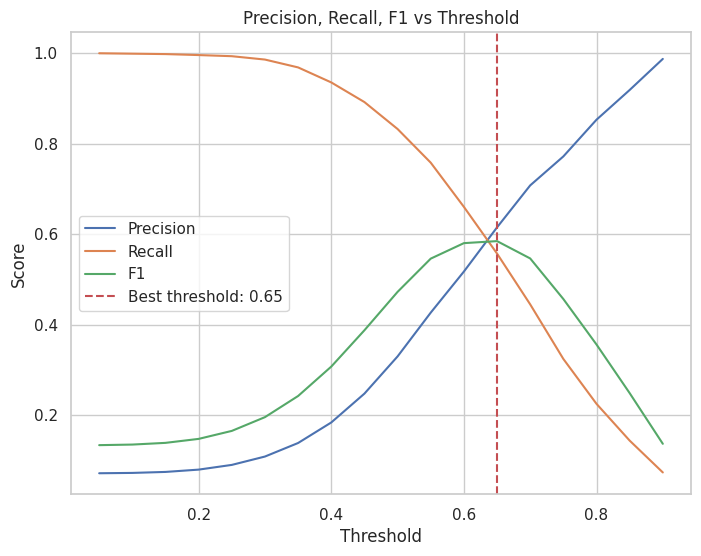

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

#  Get predictions from model
val_logits = aspect_model.predict(ds_val_all)  # shape: (num_samples, num_aspects)
val_probs = tf.sigmoid(val_logits).numpy()           # convert logits to probabilities

#  True labels
y_true = y_aspect_val  # shape: (num_samples, num_aspects)

#  Evaluate multiple thresholds
thresholds = np.arange(0.05, 0.95, 0.05)
results = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)

    p = precision_score(y_true, preds, average="micro", zero_division=0)
    r = recall_score(y_true, preds, average="micro", zero_division=0)
    f = f1_score(y_true, preds, average="micro", zero_division=0)

    results.append([t, p, r, f])

results = np.array(results)

#  Find best threshold by F1
best_idx = results[:,3].argmax()
best_threshold = results[best_idx,0]
best_precision = results[best_idx,1]
best_recall = results[best_idx,2]
best_f1 = results[best_idx,3]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Precision: {best_precision:.4f}, Recall: {best_recall:.4f}, F1: {best_f1:.4f}")

#  plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(results[:,0], results[:,1], label="Precision")
plt.plot(results[:,0], results[:,2], label="Recall")
plt.plot(results[:,0], results[:,3], label="F1")
plt.axvline(best_threshold, color='r', linestyle='--', label=f"Best threshold: {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, F1 vs Threshold")
plt.legend()
plt.show()


### Evaluation

In [ ]:
# Get predictions using the best threshold
best_preds = (val_probs >= best_threshold).astype(int)

# Compute multilabel confusion matrix
from sklearn.metrics import multilabel_confusion_matrix
cm = multilabel_confusion_matrix(y_true, best_preds)

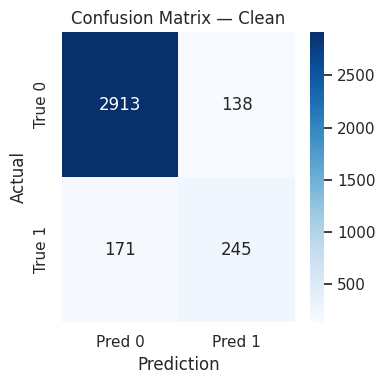

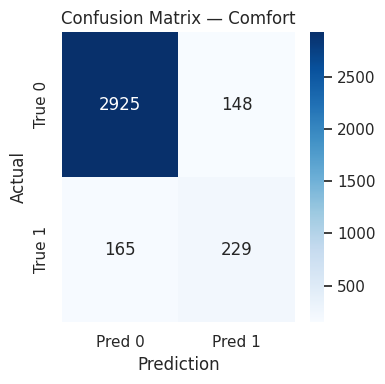

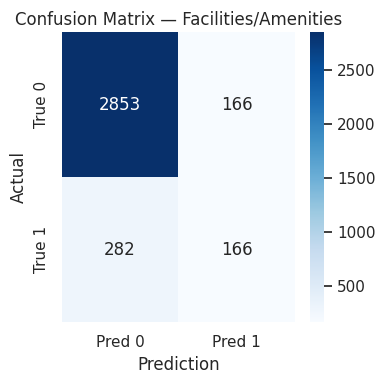

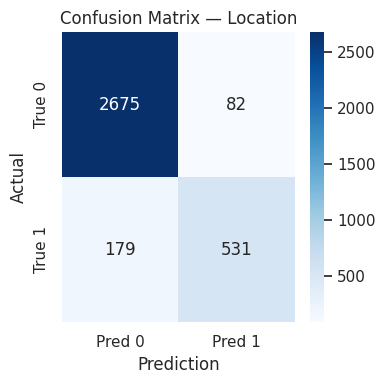

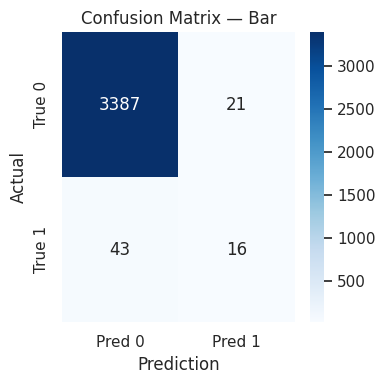

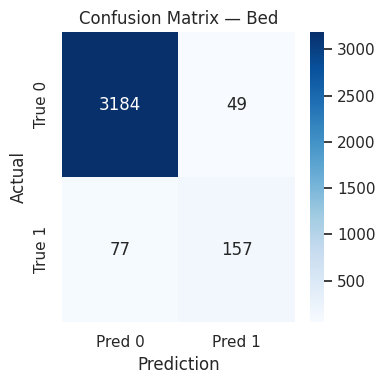

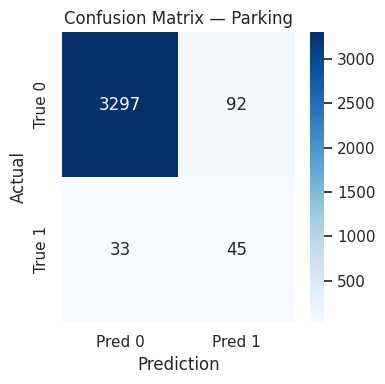

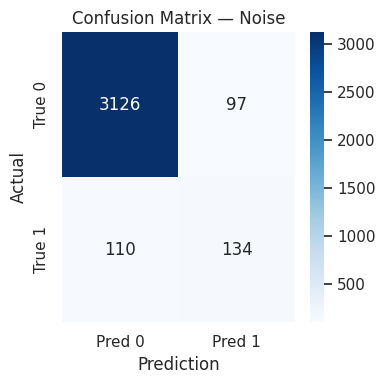

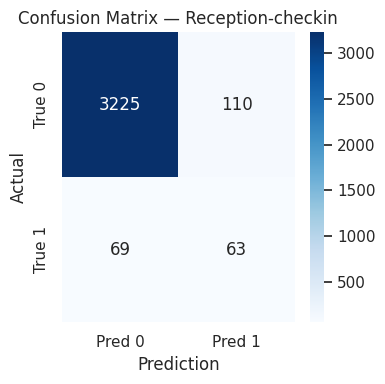

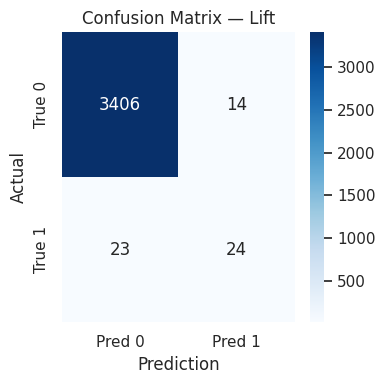

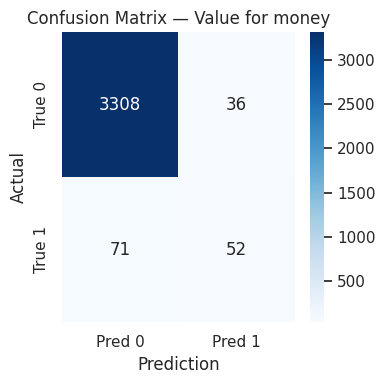

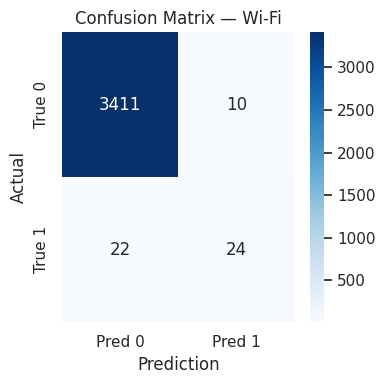

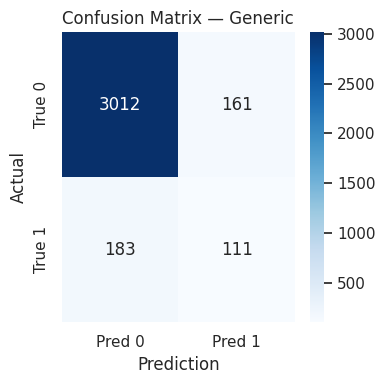

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

aspect_cols = [
    'Clean','Comfort','Facilities/Amenities','Location','Bar','Bed',
    'Parking','Noise','Reception-checkin','Lift','Value for money',
    'Wi-Fi','Generic'
]

for i, aspect in enumerate(aspect_cols):
    plt.figure(figsize=(4,4))

    sns.heatmap(
        cm[i],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Pred 0', 'Pred 1'],
        yticklabels=['True 0', 'True 1']
    )

    plt.title(f"Confusion Matrix — {aspect}")
    plt.xlabel("Prediction")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


In [ ]:
print("\n--- Aspect evaluation on TEST set ---")
test_logits = aspect_model.predict(ds_test_all)
test_probs = tf.sigmoid(test_logits).numpy()

test_preds = (test_probs >= best_threshold).astype(int)


--- Aspect evaluation on TEST set ---
217/217 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step


In [ ]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix, f1_score
print(classification_report(y_aspect_test, test_preds, target_names=ASPECT_COLS, zero_division=0))
mcm = multilabel_confusion_matrix(y_aspect_test, test_preds)

                      precision    recall  f1-score   support

               Clean       0.66      0.53      0.59       480
             Comfort       0.57      0.53      0.55       367
Facilities/Amenities       0.55      0.41      0.47       438
            Location       0.89      0.74      0.81       743
                 Bar       0.37      0.13      0.19        54
                 Bed       0.78      0.63      0.70       225
             Parking       0.32      0.55      0.40        88
               Noise       0.57      0.54      0.55       229
   Reception-checkin       0.40      0.63      0.49       131
                Lift       0.51      0.47      0.49        45
     Value for money       0.49      0.39      0.43       136
               Wi-Fi       0.59      0.48      0.53        46
             Generic       0.37      0.29      0.33       310

           micro avg       0.61      0.54      0.57      3292
           macro avg       0.54      0.48      0.50      3292
      


## Task2: SENTIMENT MODEL (SINGLE-ASPECT)


In [ ]:
encoder.trainable = False


# Inputs
input_ids_sent = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
attention_mask_sent = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')
aspect_idx_input = tf.keras.layers.Input(shape=(), dtype=tf.int32, name='aspect_idx')

# Load encoder (can freeze later)
encoder_sent = TFAutoModel.from_pretrained(MODEL_NAME, from_pt=True)

# Lambda wrapper
def encoder_forward_sent(inputs):
    input_ids, attention_mask = inputs
    outputs = encoder_sent(input_ids=input_ids, attention_mask=attention_mask)
    return outputs.last_hidden_state[:,0,:]  # CLS token

pooled_output_sent = tf.keras.layers.Lambda(encoder_forward_sent, output_shape=(hidden_size,))(
    [input_ids_sent, attention_mask_sent]
)
pooled_output_sent = tf.keras.layers.Dropout(0.2)(pooled_output_sent)

# Sentiment head
aspect_emb = tf.keras.layers.Embedding(NUM_ASPECTS, 32)(aspect_idx_input)
concat = tf.keras.layers.Concatenate()([pooled_output_sent, aspect_emb])
sent_hidden = tf.keras.layers.Dense(128, activation='relu')(concat)
sent_logits = tf.keras.layers.Dense(NUM_SENT_CLASSES, name='sent_logits')(sent_hidden)

# Build sentiment model
sent_model = tf.keras.Model(inputs=[input_ids_sent, attention_mask_sent, aspect_idx_input],
                            outputs=sent_logits)


# compile with custom weighted loss that works with tf.data
sent_model.compile(optimizer=tf.keras.optimizers.Adam(LR),
                   loss=weighted_sparse_ce_sent,
                   metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

sent_model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_transform.weight', 'vocab_projector.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 768)       │          0 │ input_ids[0][0],  │
│                     │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aspect_idx          │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 768)       │          0 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 32)        │        416 │ aspect_idx[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 800)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    102,528 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sent_logits (Dense) │ (None, 3)         │        387 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 103,331 (403.64 KB)

 Trainable params: 103,331 (403.64 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [ ]:
# Train sentiment model
history_sent_1 = sent_model.fit(ds_train_sent, validation_data=ds_val_sent, epochs=1)

# Unfreeze encoder and fine-tune (lower LR)
encoder.trainable = True
sent_model.compile(optimizer=tf.keras.optimizers.Adam(LR/2), loss=weighted_sparse_ce_sent,
                   metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])
history_sent_2 = sent_model.fit(ds_train_sent, validation_data=ds_val_sent, epochs=EPOCHS-1)


546/546 ━━━━━━━━━━━━━━━━━━━━ 57s 87ms/step - accuracy: 0.5365 - loss: 1.1368 - val_accuracy: 0.7492 - val_loss: 1.0086
Epoch 1/9
546/546 ━━━━━━━━━━━━━━━━━━━━ 57s 89ms/step - accuracy: 0.7009 - loss: 0.9478 - val_accuracy: 0.7701 - val_loss: 0.9366
Epoch 2/9
546/546 ━━━━━━━━━━━━━━━━━━━━ 35s 65ms/step - accuracy: 0.7569 - loss: 0.8583 - val_accuracy: 0.7599 - val_loss: 0.8831
Epoch 3/9
546/546 ━━━━━━━━━━━━━━━━━━━━ 36s 65ms/step - accuracy: 0.7823 - loss: 0.7952 - val_accuracy: 0.7679 - val_loss: 0.8446
Epoch 4/9
546/546 ━━━━━━━━━━━━━━━━━━━━ 36s 66ms/step - accuracy: 0.7949 - loss: 0.7560 - val_accuracy: 0.7545 - val_loss: 0.8165
Epoch 5/9
546/546 ━━━━━━━━━━━━━━━━━━━━ 35s 65ms/step - accuracy: 0.7827 - loss: 0.7245 - val_accuracy: 0.7775 - val_loss: 0.8000
Epoch 6/9
546/546 ━━━━━━━━━━━━━━━━━━━━ 35s 64ms/step - accuracy: 0.7901 - loss: 0.6984 - val_accuracy: 0.7626 - val_loss: 0.7814
Epoch 7/9
546/546 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.7907 - loss: 0.6534 - val_accuracy: 0.76

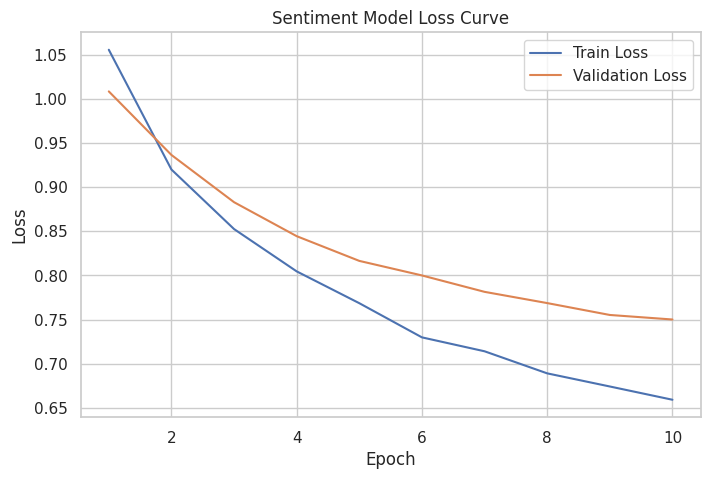

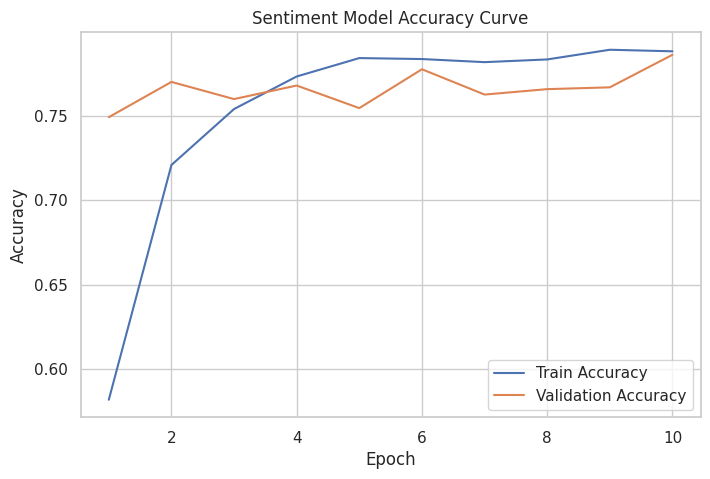

In [ ]:
import matplotlib.pyplot as plt

# Combine history dictionaries
loss = history_sent_1.history['loss'] + history_sent_2.history['loss']
val_loss = history_sent_1.history['val_loss'] + history_sent_2.history['val_loss']
acc = history_sent_1.history['accuracy'] + history_sent_2.history['accuracy']
val_acc = history_sent_1.history['val_accuracy'] + history_sent_2.history['val_accuracy']

epochs = range(1, len(loss)+1)

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sentiment Model Loss Curve")
plt.legend()
plt.show()

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(epochs, acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Sentiment Model Accuracy Curve")
plt.legend()
plt.show()


### Sentiment Analysis Evaluation

In [ ]:
val_logits = sent_model.predict(ds_test_sent)
val_preds = np.argmax(val_logits, axis=-1)
print("\n--- Sentiment evaluation (test set) ---")
print(classification_report(y_sent_test, val_preds, target_names=['negative','neutral','positive'], zero_division=0))


117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step

--- Sentiment evaluation (test set) ---
              precision    recall  f1-score   support

    negative       0.93      0.78      0.85       940
     neutral       0.11      0.49      0.18        69
    positive       0.95      0.84      0.89       861

    accuracy                           0.80      1870
   macro avg       0.66      0.71      0.64      1870
weighted avg       0.91      0.80      0.84      1870



117/117 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step
y_true_test.shape: (1870,)
test_preds.shape: (1870,)


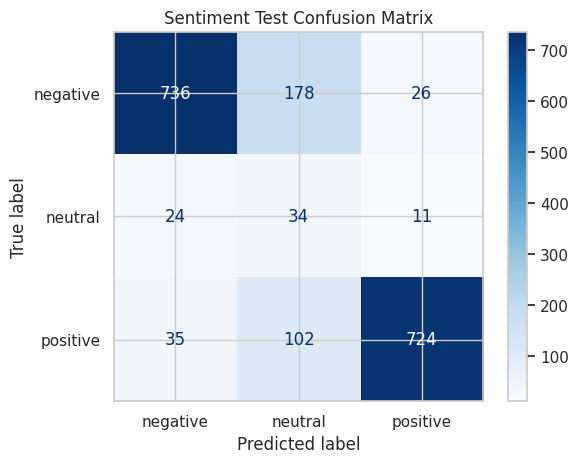

In [ ]:
#  Tokenize test texts
enc_test = tokenizer(X_test_single, truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors="tf")

#  Make test dataset for sentiment model
ds_test_single = tf.data.Dataset.from_tensor_slices({
    "input_ids": enc_test["input_ids"],
    "attention_mask": enc_test["attention_mask"],
    "aspect_idx": y_aspect_idx_test
}).batch(BATCH_SIZE)

#  Predict on test set
test_logits = sent_model.predict(ds_test_single)
test_preds = np.argmax(test_logits, axis=-1)

#  Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_test = y_sent_test
print("y_true_test.shape:", y_true_test.shape)
print("test_preds.shape:", test_preds.shape)

cm = confusion_matrix(y_true_test, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['negative','neutral','positive'])
disp.plot(cmap="Blues")
plt.title("Sentiment Test Confusion Matrix")
plt.show()


# New Architecture - Multi-head Models

## Sentence-level Multi-task BERT

In [24]:
def make_multi_task_dataset(encodings, aspect_idx, sent_labels, batch_size=BATCH_SIZE, shuffle=False):
    # aspect multi-hot per sample (sentence-level)
    # create sentence-level multi-hot vectors (shape (N, NUM_ASPECTS))
    y_aspect_sentence = np.zeros((len(aspect_idx), NUM_ASPECTS), dtype=np.float32)
    for i, aidx in enumerate(aspect_idx):
        y_aspect_sentence[i, aidx] = 1.0
    ds = tf.data.Dataset.from_tensor_slices((
        {'input_ids': encodings['input_ids'], 'attention_mask': encodings['attention_mask'], 'aspect_idx': aspect_idx},
        {'aspect_logits': y_aspect_sentence, 'sent_logits': sent_labels}
    ))
    if shuffle:
        ds = ds.shuffle(2048, seed=RANDOM_STATE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

ds_train_mt = make_multi_task_dataset(enc_train_single, y_aspect_idx_train, y_sent_train, shuffle=True)
ds_val_mt   = make_multi_task_dataset(enc_val_single, y_aspect_idx_val, y_sent_val, shuffle=False)


In [25]:
# Define the encoder function for the Lambda layer
def encoder_forward(inputs):
    input_ids, attention_mask = inputs
    outputs = distilbert(input_ids=input_ids, attention_mask=attention_mask)
    last_hidden = outputs.last_hidden_state          # (batch, seq_len, 768)
    cls_token = last_hidden[:, 0, :]                # take CLS token
    return cls_token

In [26]:
encoder = TFAutoModel.from_pretrained(MODEL_NAME, from_pt=True)
hidden_size = encoder.config.hidden_size
# Inputs
input_ids_mt = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name='input_ids')
attention_mt = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name='attention_mask')
aspect_idx_mt = tf.keras.layers.Input(shape=(), dtype=tf.int32, name='aspect_idx')   # used for sentiment head only

seq_cls = tf.keras.layers.Lambda(encoder_forward, output_shape=(hidden_size,))([input_ids_mt, attention_mt])
seq_cls = tf.keras.layers.Dropout(0.2)(seq_cls)

# Aspect head (sentence-level, multi-label)
aspect_logits_mt = tf.keras.layers.Dense(NUM_ASPECTS, name='aspect_logits')(seq_cls)

# Sentiment head (use same pooled CLS)
aspect_emb_mt = tf.keras.layers.Embedding(NUM_ASPECTS, 32)(aspect_idx_mt)
sent_concat_mt = tf.keras.layers.Concatenate(axis=-1)([seq_cls, aspect_emb_mt])
sent_hidden_mt = tf.keras.layers.Dense(128, activation='relu')(sent_concat_mt)
sent_logits_mt = tf.keras.layers.Dense(NUM_SENT_CLASSES, name='sent_logits')(sent_hidden_mt)

multi_task_model = tf.keras.Model(inputs=[input_ids_mt, attention_mt, aspect_idx_mt],
                                  outputs=[aspect_logits_mt, sent_logits_mt])


pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.weight', 'vocab_projector.weight', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the mode

### Training

In [ ]:
# compile with appropriate losses
multi_task_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss={
        'aspect_logits': weighted_bce_aspect,
        'sent_logits': weighted_sparse_ce_sent
    },
    metrics={
        'aspect_logits': [tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')],
        'sent_logits': [tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
    }
)


In [ ]:
# Train (try small number of epochs first)
encoder.trainable = False
history_multi_sent1 = multi_task_model.fit(ds_train_mt, validation_data=ds_val_mt, epochs=3)
encoder.trainable = True
history_multi_sent1 = multi_task_model.fit(ds_train_mt, validation_data=ds_val_mt, epochs=EPOCHS-3)

Epoch 1/3
546/546 ━━━━━━━━━━━━━━━━━━━━ 66s 86ms/step - aspect_logits_loss: 1.3755 - aspect_logits_precision: 0.1163 - aspect_logits_recall: 0.1645 - loss: 2.5197 - sent_logits_accuracy: 0.6193 - sent_logits_loss: 1.1441 - val_aspect_logits_loss: 1.2745 - val_aspect_logits_precision: 0.3985 - val_aspect_logits_recall: 0.1123 - val_loss: 2.2409 - val_sent_logits_accuracy: 0.7840 - val_sent_logits_loss: 0.9672
Epoch 2/3
546/546 ━━━━━━━━━━━━━━━━━━━━ 36s 66ms/step - aspect_logits_loss: 1.2871 - aspect_logits_precision: 0.2107 - aspect_logits_recall: 0.2638 - loss: 2.1681 - sent_logits_accuracy: 0.7439 - sent_logits_loss: 0.8810 - val_aspect_logits_loss: 1.2206 - val_aspect_logits_precision: 0.5937 - val_aspect_logits_recall: 0.2422 - val_loss: 2.0912 - val_sent_logits_accuracy: 0.8219 - val_sent_logits_loss: 0.8713
Epoch 3/3
546/546 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - aspect_logits_loss: 1.2459 - aspect_logits_precision: 0.2691 - aspect_logits_recall: 0.3268 - loss: 2.0308 - sent_logits_ac

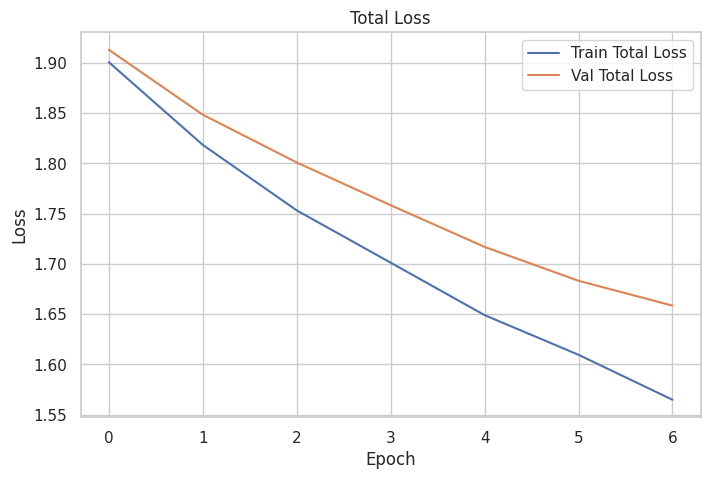

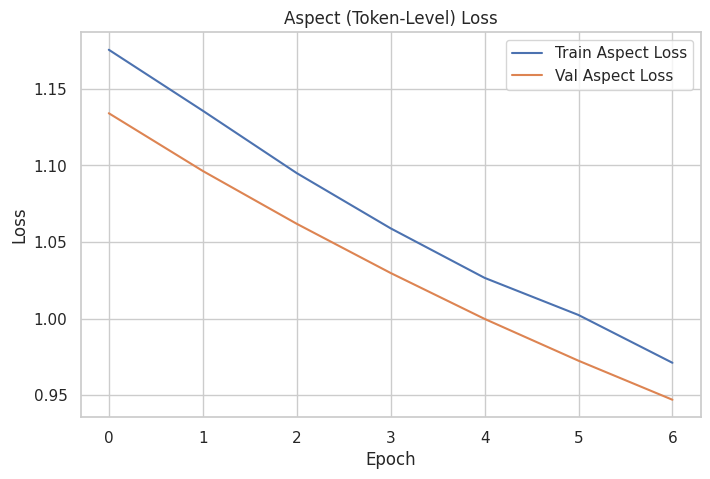

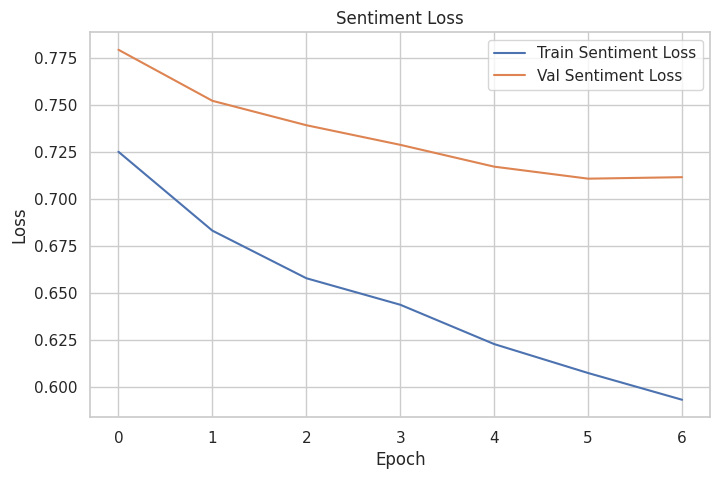

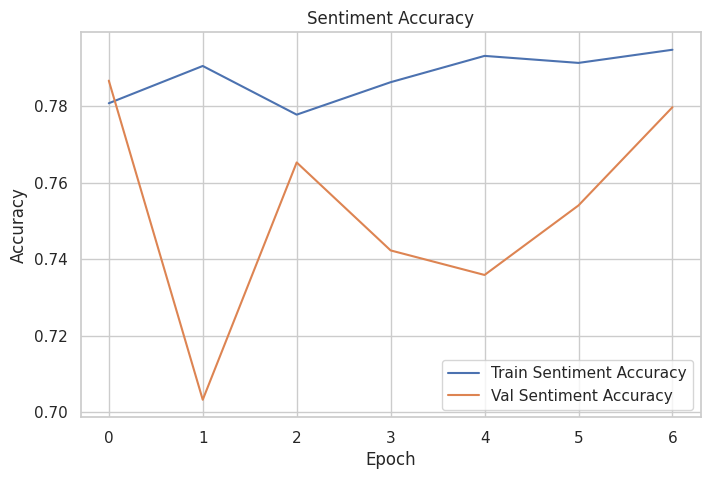

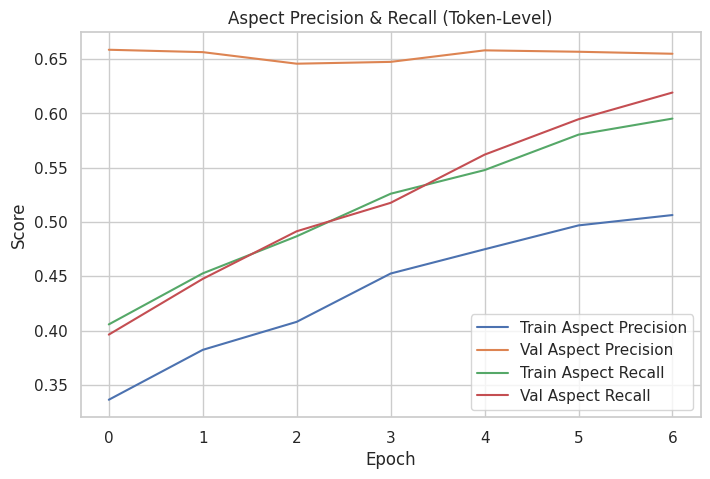

In [ ]:
import matplotlib.pyplot as plt


history_dict = history_multi_sent1.history

# --- Plot total loss ---
plt.figure(figsize=(8,5))
plt.plot(history_dict["loss"], label="Train Total Loss")
plt.plot(history_dict["val_loss"], label="Val Total Loss")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- Plot aspect loss ---
plt.figure(figsize=(8,5))
plt.plot(history_dict["aspect_logits_loss"], label="Train Aspect Loss")
plt.plot(history_dict["val_aspect_logits_loss"], label="Val Aspect Loss")
plt.title("Aspect (Token-Level) Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- Plot sentiment loss ---
plt.figure(figsize=(8,5))
plt.plot(history_dict["sent_logits_loss"], label="Train Sentiment Loss")
plt.plot(history_dict["val_sent_logits_loss"], label="Val Sentiment Loss")
plt.title("Sentiment Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- Plot sentiment accuracy ---
plt.figure(figsize=(8,5))
plt.plot(history_dict["sent_logits_accuracy"], label="Train Sentiment Accuracy")
plt.plot(history_dict["val_sent_logits_accuracy"], label="Val Sentiment Accuracy")
plt.title("Sentiment Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Optional: plot aspect precision & recall
plt.figure(figsize=(8,5))
plt.plot(history_dict["aspect_logits_precision"], label="Train Aspect Precision")
plt.plot(history_dict["val_aspect_logits_precision"], label="Val Aspect Precision")
plt.plot(history_dict["aspect_logits_recall"], label="Train Aspect Recall")
plt.plot(history_dict["val_aspect_logits_recall"], label="Val Aspect Recall")
plt.title("Aspect Precision & Recall (Token-Level)")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()


### Evaluation

In [ ]:
# Tokenize the test texts
test_encodings = tokenizer(
    X_test_single,                # list of raw text
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='tf'
)

# Extract the input tensors
X_test_input_ids = test_encodings['input_ids']
X_test_attention = test_encodings['attention_mask']

# The aspect indices are already correct
aspect_idx_test_input = y_aspect_idx_test


In [ ]:
# Predict on test set
aspect_logits_test, sent_logits_test = multi_task_model.predict([X_test_input_ids, X_test_attention, y_aspect_idx_test])

# Aspect predictions (multi-label)
aspect_preds_test = (aspect_logits_test > 0.65).astype(int)

# Sentiment predictions (for the selected aspect)
sent_preds_test = np.argmax(sent_logits_test, axis=1)

# True labels
y_true_aspect_test = np.zeros_like(aspect_preds_test)
y_true_aspect_test[np.arange(len(y_aspect_idx_test)), y_aspect_idx_test] = 1  # one-hot for sentence-level aspect
y_true_sent_test = y_sent_test


59/59 ━━━━━━━━━━━━━━━━━━━━ 52s 871ms/step


=== Aspect Classification Report ===
                      precision    recall  f1-score   support

               Clean       0.67      0.51      0.58       217
             Comfort       0.76      0.08      0.15       154
Facilities/Amenities       0.64      0.58      0.61       317
            Location       0.92      0.76      0.83       516
                 Bar       0.75      0.21      0.32        29
                 Bed       1.00      0.01      0.03        75
             Parking       0.62      0.60      0.61        30
               Noise       0.69      0.55      0.61       153
   Reception-checkin       0.55      0.66      0.60       102
                Lift       0.50      0.10      0.17        30
     Value for money       0.86      0.38      0.53        65
               Wi-Fi       0.79      0.71      0.75        31
             Generic       0.70      0.19      0.29       151

           micro avg       0.75      0.51      0.60      1870
           macro avg       0.73

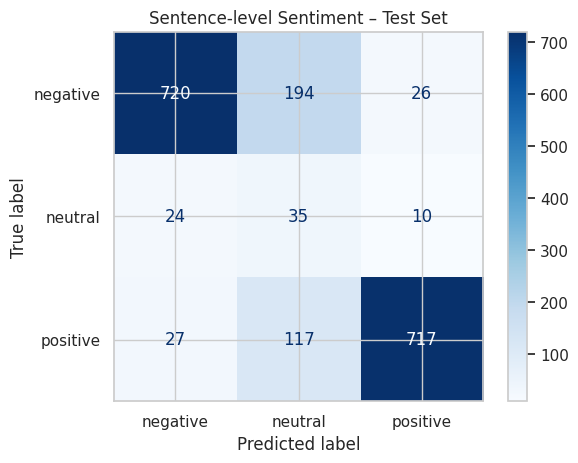

=== Sentiment Classification Report ===
              precision    recall  f1-score   support

    negative       0.93      0.77      0.84       940
     neutral       0.10      0.51      0.17        69
    positive       0.95      0.83      0.89       861

    accuracy                           0.79      1870
   macro avg       0.66      0.70      0.63      1870
weighted avg       0.91      0.79      0.84      1870



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Aspect confusion & F1
print("=== Aspect Classification Report ===")
print(classification_report(y_true_aspect_test, aspect_preds_test, target_names=ASPECT_COLS, zero_division=0))

# Sentiment confusion & F1
cm_sent = confusion_matrix(y_true_sent_test, sent_preds_test)
disp = ConfusionMatrixDisplay(cm_sent, display_labels=['negative','neutral','positive'])
disp.plot(cmap="Blues")
plt.title("Sentence-level Sentiment – Test Set")
plt.show()

print("=== Sentiment Classification Report ===")
print(classification_report(y_true_sent_test, sent_preds_test, target_names=['negative','neutral','positive'], zero_division=0))


For aspect classification, the model achieves a micro F1 of 0.60 and a macro F1 of 0.47, indicating good performance on frequent aspects like Location (F1=0.83), Wi-Fi (F1=0.75), and Facilities/Amenities (F1=0.61), but poor performance on rare aspects such as Bed (F1=0.03), Comfort (F1=0.15), and Lift (F1=0.17). For sentiment classification, overall accuracy is 0.79 with a weighted F1 of 0.84, showing strong performance on dominant classes positive and negative (F1>0.8), but weak performance on the neutral class (F1=0.17) due to its small sample size, leading to low precision. To improve results, consider adjusting thresholds per aspect, augmenting rare classes, or applying additional class weighting, especially for rare aspects and the neutral sentiment class.

## Build Multi-head BERT - combined token-level aspect detection with sentence-level sentiment classification

In [ ]:
def make_multi_task_dataset(encodings, aspect_labels, sent_labels, batch_size=BATCH_SIZE, shuffle=False):
    # ensure float32
    aspect_labels = aspect_labels.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((
        {
            'input_ids': encodings['input_ids'],
            'attention_mask': encodings['attention_mask']
        },
        {
            'sentence_aspect_output': aspect_labels,   # match model output
            'sentiment_output': sent_labels
        }
    ))
    if shuffle:
        ds = ds.shuffle(2048, seed=RANDOM_STATE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [ ]:
import numpy as np

def make_token_labels(aspect_idx, encodings, num_aspects, max_len):
    """
    Create token-level multi-hot labels for single-aspect sentences.
    aspect_idx: array of sentence-level aspect indices (0..NUM_ASPECTS-1)
    encodings: tokenized inputs (from tokenizer)
    Returns: numpy array of shape (num_sentences, max_len, num_aspects)
    """
    n_samples = len(aspect_idx)
    token_labels = np.zeros((n_samples, max_len, num_aspects), dtype=np.float32)

    for i, idx in enumerate(aspect_idx):
        # Mark the whole sentence tokens as belonging to the aspect
        input_len = np.sum(encodings['attention_mask'][i])  # number of real tokens
        token_labels[i, :input_len, idx] = 1.0
    return token_labels

y_aspect_train_single = make_token_labels(
    y_aspect_idx_train, enc_train_single, NUM_ASPECTS, MAX_LEN
)

y_aspect_val_single = make_token_labels(
    y_aspect_idx_val, enc_val_single, NUM_ASPECTS, MAX_LEN
)

y_aspect_test_single = make_token_labels(
    y_aspect_idx_test, enc_test_single, NUM_ASPECTS, MAX_LEN
)


# Collapse token-level labels to sentence-level (max over tokens)
y_aspect_train_sentence = np.max(y_aspect_train_single, axis=1)  # shape: (num_samples, NUM_ASPECTS)
y_aspect_val_sentence   = np.max(y_aspect_val_single, axis=1)
y_aspect_test_sentence  = np.max(y_aspect_test_single, axis=1)




In [ ]:
ds_train_multi = make_multi_task_dataset(enc_train_single, y_aspect_train_sentence, y_sent_train, shuffle=True)
ds_val_multi   = make_multi_task_dataset(enc_val_single, y_aspect_val_sentence, y_sent_val)
ds_test_multi  = make_multi_task_dataset(enc_test_single, y_aspect_test_sentence, y_sent_test)


## Failed Approach

In [ ]:
from transformers import TFDistilBertModel

# --- Inputs ---
input_ids = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")

# --- Encoder ---
distilbert = TFDistilBertModel.from_pretrained(MODEL_NAME, from_pt=True)

def distilbert_encoder(inputs):
    input_ids, attention_mask = inputs
    return distilbert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state

sequence_output = tf.keras.layers.Lambda(distilbert_encoder, output_shape=(MAX_LEN, distilbert.config.hidden_size))(
    [input_ids, attention_mask]
)

# --- Token-level aspect head ---
aspect_logits = tf.keras.layers.Dense(NUM_ASPECTS, activation='sigmoid', name="token_aspect_output")(sequence_output)

# --- Sentence-level sentiment head ---
cls_token = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=1))(sequence_output)
sentiment_logits = tf.keras.layers.Dense(NUM_SENT_CLASSES, activation='softmax', name="sentiment_output")(cls_token)

# --- Final model ---
model_token_multi = tf.keras.Model(
    inputs=[input_ids, attention_mask],
    outputs=[aspect_logits, sentiment_logits]
)


pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_projector.weight', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [ ]:

from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=LR)

# --- Compile token-level multi-task model ---
model_token_multi.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss={
        'token_aspect_output': weighted_bce_aspect,
        'sentiment_output': weighted_sparse_ce_sent
    },
    metrics={
        'token_aspect_output': [tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')],
        'sentiment_output': [tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
    }
)




In [ ]:
history_token_multi = model_token_multi.fit(
    ds_train_multi,
    validation_data=ds_val_multi,
    epochs=EPOCHS
)


Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step - loss: 2.0266 - sentiment_output_accuracy: 0.6413 - sentiment_output_loss: 1.0809 - token_aspect_output_loss: 0.9457 - token_aspect_output_precision: 0.0142 - token_aspect_output_recall: 0.1697 - val_loss: 1.9872 - val_sentiment_output_accuracy: 0.7422 - val_sentiment_output_loss: 1.1281 - val_token_aspect_output_loss: 0.8604 - val_token_aspect_output_precision: 0.0323 - val_token_aspect_output_recall: 0.0136
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 36s 66ms/step - loss: 1.9083 - sentiment_output_accuracy: 0.7632 - sentiment_output_loss: 1.0613 - token_aspect_output_loss: 0.8470 - token_aspect_output_precision: 0.0347 - token_aspect_output_recall: 0.0109 - val_loss: 1.9171 - val_sentiment_output_accuracy: 0.7979 - val_sentiment_output_loss: 1.1068 - val_token_aspect_output_loss: 0.8115 - val_token_aspect_output_precision: 0.0401 - val_token_aspect_output_recall: 0.0056
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - loss: 1.

In [ ]:
import matplotlib.pyplot as plt

history_dict = history_token_multi.history

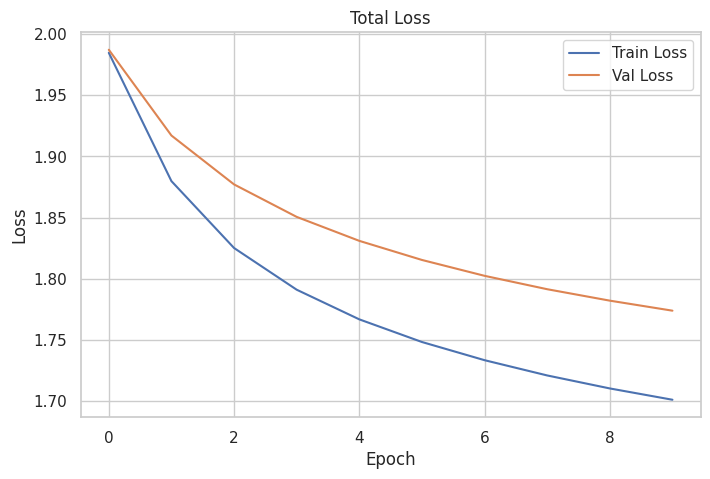

In [ ]:
# Plot total loss
plt.figure(figsize=(8,5))
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Val Loss")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


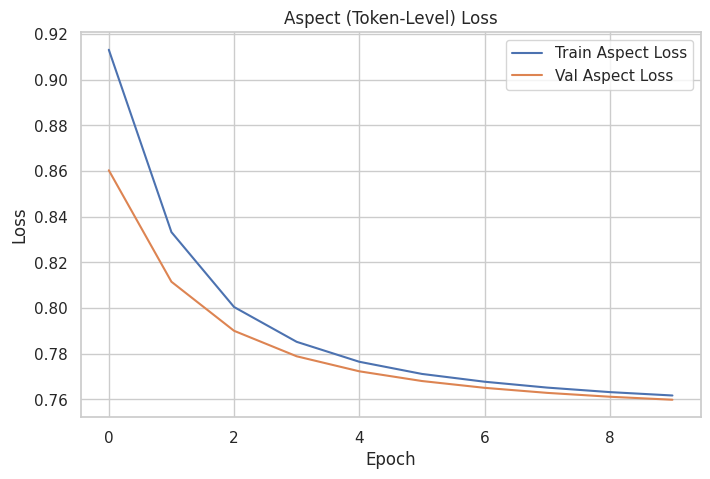

In [ ]:
# Plot aspect loss
# Aspect (token-level) loss
plt.figure(figsize=(8,5))
plt.plot(history_dict["token_aspect_output_loss"], label="Train Aspect Loss")
plt.plot(history_dict["val_token_aspect_output_loss"], label="Val Aspect Loss")
plt.title("Aspect (Token-Level) Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

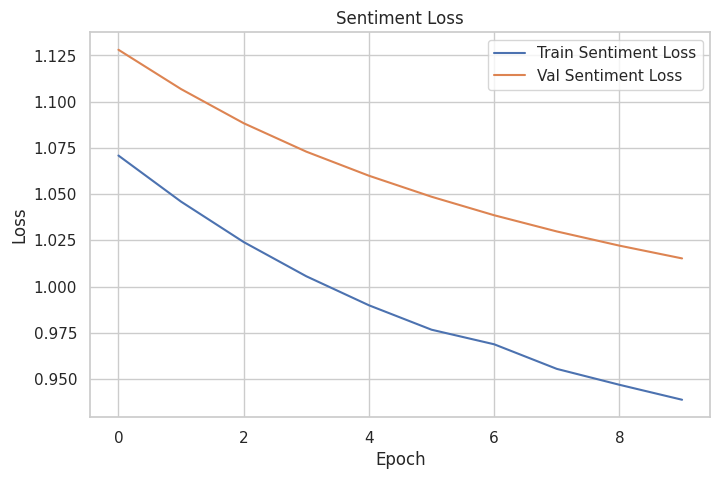

In [ ]:
# Plot sentiment loss
plt.figure(figsize=(8,5))
plt.plot(history_dict["sentiment_output_loss"], label="Train Sentiment Loss")
plt.plot(history_dict["val_sentiment_output_loss"], label="Val Sentiment Loss")
plt.title("Sentiment Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


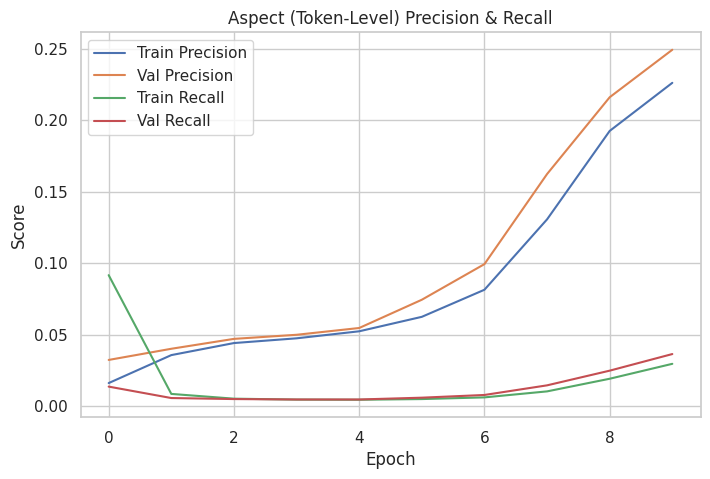

In [ ]:
# Plot aspect precision & recall
plt.figure(figsize=(8,5))
plt.plot(history_dict["token_aspect_output_precision"], label="Train Precision")
plt.plot(history_dict["val_token_aspect_output_precision"], label="Val Precision")
plt.plot(history_dict["token_aspect_output_recall"], label="Train Recall")
plt.plot(history_dict["val_token_aspect_output_recall"], label="Val Recall")
plt.title("Aspect (Token-Level) Precision & Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()

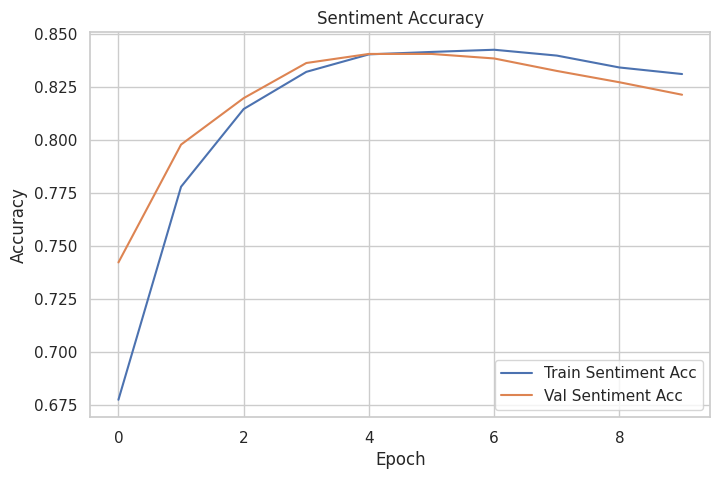

In [ ]:
# Plot sentiment accuracy
plt.figure(figsize=(8,5))
plt.plot(history_dict["sentiment_output_accuracy"], label="Train Sentiment Acc")
plt.plot(history_dict["val_sentiment_output_accuracy"], label="Val Sentiment Acc")
plt.title("Sentiment Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
# Validation predictions
y_pred_aspect, y_pred_sentiment = model_token_multi.predict(ds_val_sent)

# Test predictions
test_pred_aspect, test_pred_sentiment = model_token_multi.predict(ds_test_sent)



117/117 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step


In [ ]:
import numpy as np

# True labels for sentiment (validation)
y_true_sent = np.array(y_sent_val)  # or y_sent_val_single if you have that name

# Predicted labels from the model
y_pred_sent = np.argmax(y_pred_sentiment, axis=1)

# Classification report
from sklearn.metrics import classification_report, confusion_matrix


# Confusion matrix
cm_sent = confusion_matrix(y_true_sent, y_pred_sent)




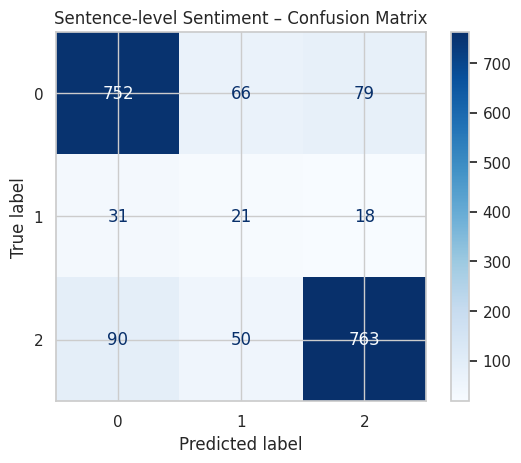

In [ ]:
# Confusion matrix for sentiment
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_sent, y_pred_sent)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Sentence-level Sentiment – Confusion Matrix")
plt.show()


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_true_sent, y_pred_sent))


              precision    recall  f1-score   support

           0       0.86      0.84      0.85       897
           1       0.15      0.30      0.20        70
           2       0.89      0.84      0.87       903

    accuracy                           0.82      1870
   macro avg       0.63      0.66      0.64      1870
weighted avg       0.85      0.82      0.83      1870



In [ ]:
# y_pred_aspect: (num_samples, MAX_LEN, NUM_ASPECTS)
# Threshold predictions
aspect_preds = (y_pred_aspect > 0.1).astype(int)

# y_true_aspect must have same shape
y_true_aspect = y_aspect_val_single  # shape: (num_samples, MAX_LEN, NUM_ASPECTS)

# Flatten to compute F1
y_true_flat = y_true_aspect.reshape(-1, NUM_ASPECTS)
y_pred_flat = aspect_preds.reshape(-1, NUM_ASPECTS)

from sklearn.metrics import f1_score, classification_report, confusion_matrix

f1_per_aspect = f1_score(y_true_flat, y_pred_flat, average=None)
print("F1 per aspect:", f1_per_aspect)


F1 per aspect: [0.07837898 0.06655462 0.09340463 0.13354141 0.02170963 0.02466488
 0.04571148 0.05967024 0.07365793 0.02086438 0.03743316 0.01491301
 0.05938242]


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

best_threshold = 0.0
best_f1 = 0.0
thresholds = np.arange(0.05, 0.95, 0.05)

# y_pred_aspect: model sigmoid outputs (num_samples, MAX_LEN, NUM_ASPECTS)
# y_aspect_val_single: true token-level labels (same shape)

for t in thresholds:
    aspect_preds = (y_pred_aspect > t).astype(int)
    f1 = f1_score(y_aspect_val_single.reshape(-1, NUM_ASPECTS),
                  aspect_preds.reshape(-1, NUM_ASPECTS),
                  average='micro')  # or 'macro' if you prefer
    print(f"Threshold {t:.2f} -> F1: {f1:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best threshold: {best_threshold:.2f}, Best F1: {best_f1:.4f}")


Threshold 0.05 -> F1: 0.0576
Threshold 0.10 -> F1: 0.0691
Threshold 0.15 -> F1: 0.0684
Threshold 0.20 -> F1: 0.0647
Threshold 0.25 -> F1: 0.0586
Threshold 0.30 -> F1: 0.0489
Threshold 0.35 -> F1: 0.0392
Threshold 0.40 -> F1: 0.0300
Threshold 0.45 -> F1: 0.0212
Threshold 0.50 -> F1: 0.0139
Threshold 0.55 -> F1: 0.0091
Threshold 0.60 -> F1: 0.0058
Threshold 0.65 -> F1: 0.0032
Threshold 0.70 -> F1: 0.0024
Threshold 0.75 -> F1: 0.0007
Threshold 0.80 -> F1: 0.0003
Threshold 0.85 -> F1: 0.0000
Threshold 0.90 -> F1: 0.0000
Best threshold: 0.10, Best F1: 0.0691


### Evaluate TOKEN-LEVEL aspect predictions

In [ ]:
y_pred_aspect, y_pred_sent = model_token_multi.predict(ds_test_multi)
aspect_preds = (y_pred_aspect > 0.1).astype(int)

# Flatten for F1 computation
y_true_flat = y_aspect_test_single.reshape(-1, NUM_ASPECTS)
y_pred_flat = aspect_preds.reshape(-1, NUM_ASPECTS)

from sklearn.metrics import f1_score, classification_report

f1_per_aspect = f1_score(y_true_flat, y_pred_flat, average=None)
print("F1 per aspect:", f1_per_aspect)

# Sentence-level sentiment
y_true_sent = y_sent_test
y_pred_sent_cls = np.argmax(y_pred_sent, axis=1)
from sklearn.metrics import classification_report
print(classification_report(y_true_sent, y_pred_sent_cls))


117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step
F1 per aspect: [0.07617696 0.07501631 0.08701175 0.19075083 0.02314165 0.03636364
 0.04115895 0.05557099 0.1454393  0.02866131 0.04891304 0.05359318
 0.06298277]
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       940
           1       0.11      0.20      0.14        69
           2       0.89      0.88      0.89       861

    accuracy                           0.84      1870
   macro avg       0.63      0.64      0.63      1870
weighted avg       0.86      0.84      0.85      1870



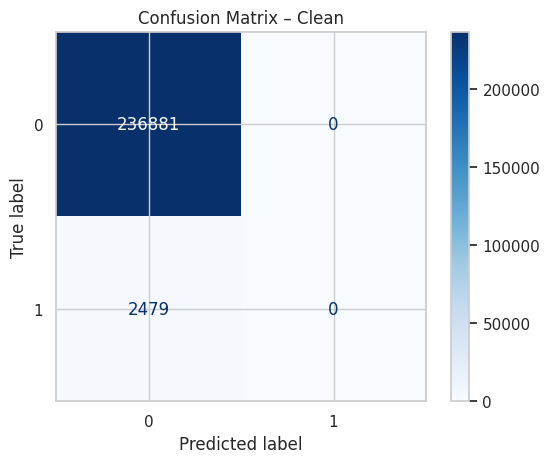

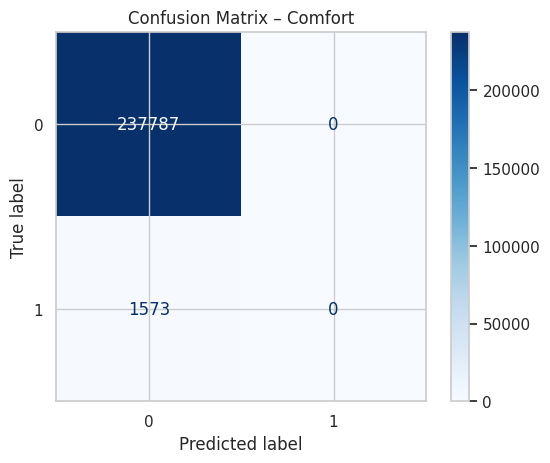

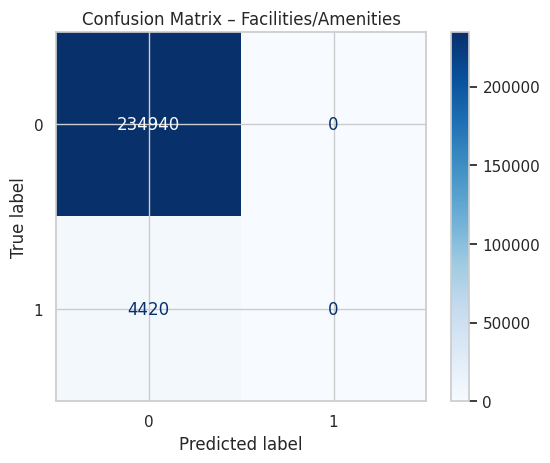

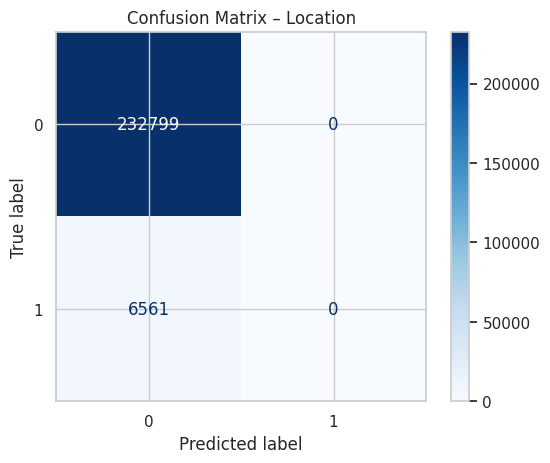

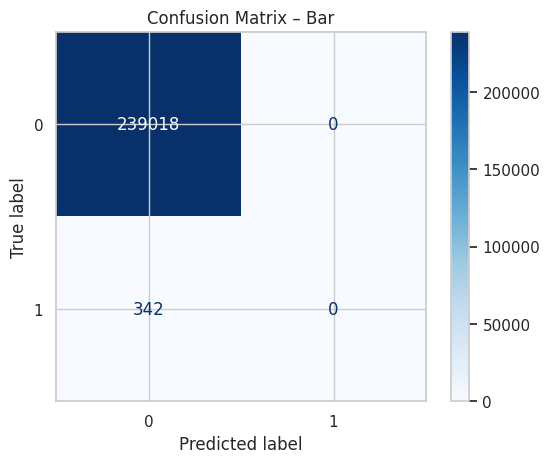

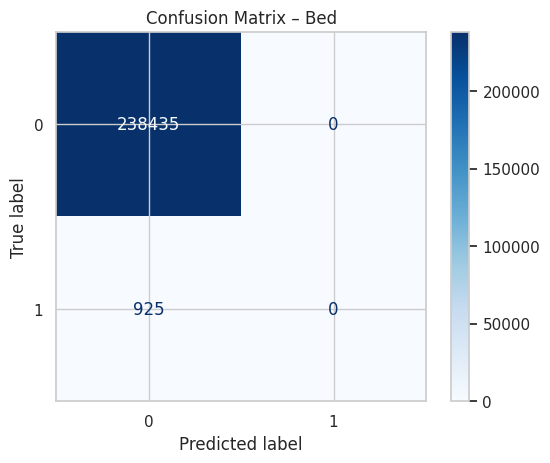

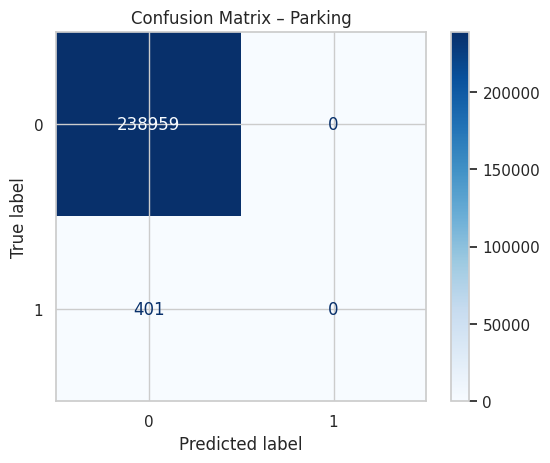

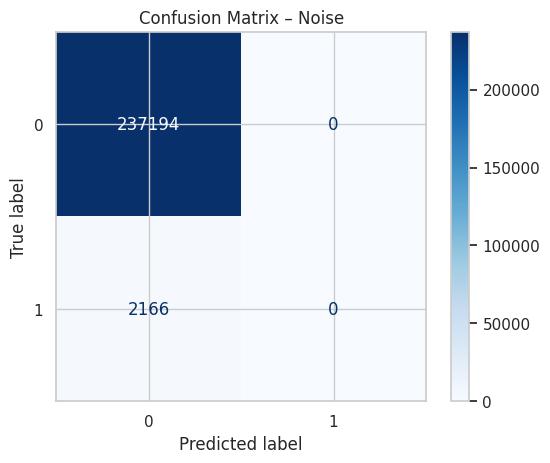

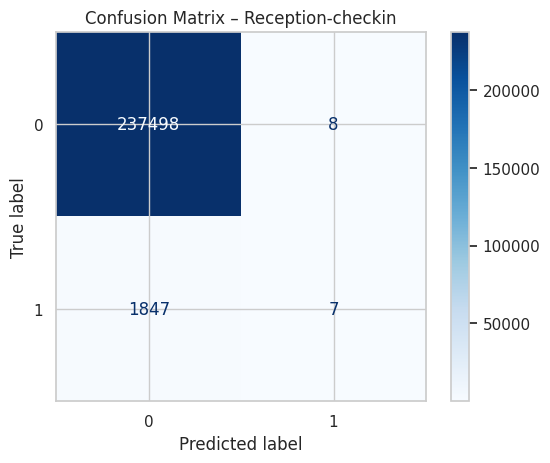

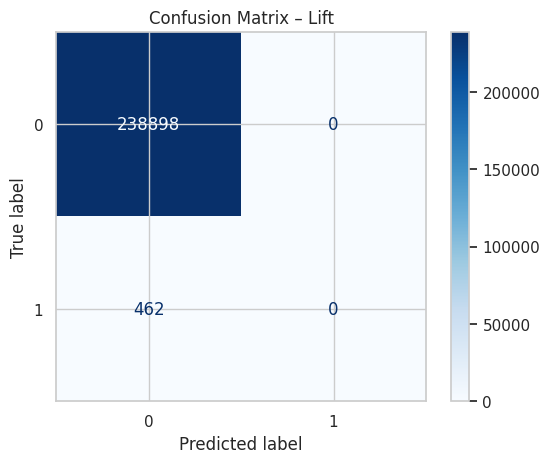

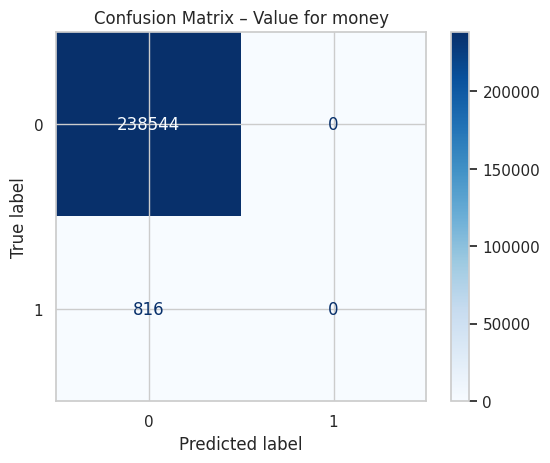

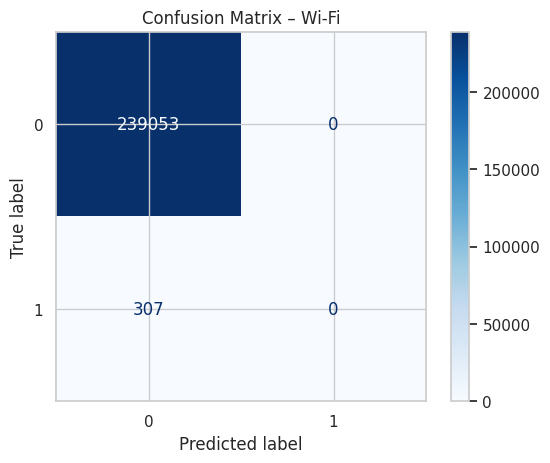

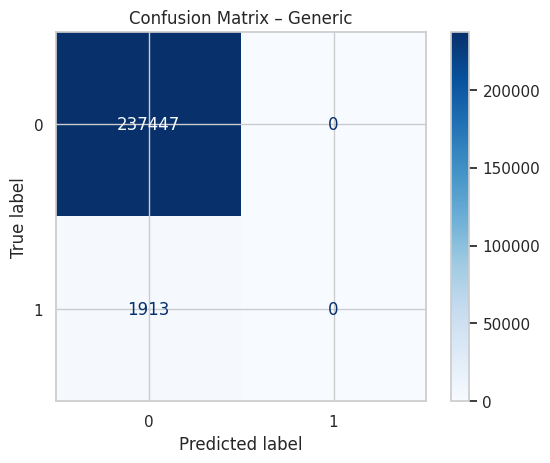

In [ ]:
y_true_flat = y_aspect_test_single.reshape(-1, NUM_ASPECTS)
y_pred_flat = aspect_preds.reshape(-1, NUM_ASPECTS)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for i, aspect_name in enumerate(ASPECT_COLS):
    cm = confusion_matrix(y_true_flat[:, i], y_pred_flat[:, i])
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix – {aspect_name}")
    plt.show()


In [ ]:
# Evaluate model using model.evaluate()
loss, aspect_loss, aspect_precision, aspect_recall, sentiment_acc, sentiment_loss = \
    model_token_multi.evaluate(ds_test_multi)

print("Total loss:", loss)
print("Aspect loss:", aspect_loss)
print("Aspect Precision:", aspect_precision)
print("Aspect Recall:", aspect_recall)
print("Sentiment Accuracy:", sentiment_acc)


117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 1.7689 - sentiment_output_accuracy: 0.8196 - sentiment_output_loss: 1.0077 - token_aspect_output_loss: 0.7612 - token_aspect_output_precision: 0.2499 - token_aspect_output_recall: 0.0365
Total loss: 1.7716933488845825
Aspect loss: 0.7597113847732544
Aspect Precision: 1.011572241783142
Aspect Recall: 0.8363636136054993
Sentiment Accuracy: 0.2598996162414551


117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step


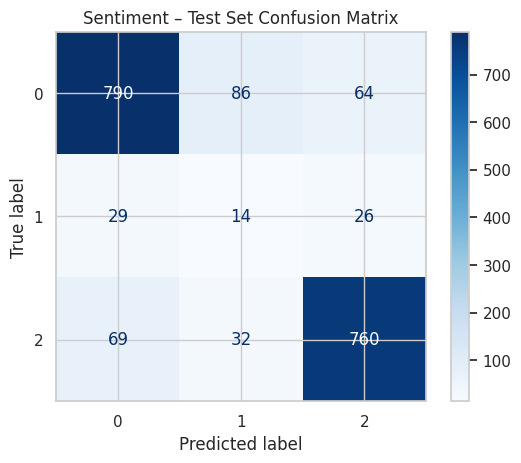

In [ ]:
# Get predictions
test_pred_aspect, test_pred_sentiment = model_token_multi.predict(ds_test_single)

# Sentiment confusion matrix
y_true_test_sent = np.array(y_sent_test)
y_pred_test_sent = np.argmax(test_pred_sentiment, axis=1)

cm = confusion_matrix(y_true_test_sent, y_pred_test_sent)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.title("Sentiment – Test Set Confusion Matrix")
plt.show()




In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true_test_tok, y_pred_test_tok, zero_division=0))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00     27776
           1       0.00      0.00      0.00     19712
           2       0.15      0.00      0.00     40576
           3       0.43      0.00      0.00     66048
           4       0.00      0.00      0.00      3712
           5       0.00      0.00      0.00      9600
           6       0.20      0.00      0.00      3840
           7       0.04      0.00      0.00     19584
           8       0.34      0.06      0.10     13056
           9       0.07      0.00      0.00      3840
          10       0.15      0.00      0.00      8320
          11       0.06      0.01      0.02      3968
          12       0.00      0.00      0.00     19328

   micro avg       0.26      0.00      0.01    239360
   macro avg       0.11      0.01      0.01    239360
weighted avg       0.18      0.00      0.01    239360
 samples avg       0.00      0.00      0.00    239360



## Success Approach

In [ ]:
# aspect detection in token_level
import tensorflow as tf
from transformers import TFDistilBertModel
from tensorflow.keras.optimizers import Adam



# Keras Inputs
input_ids = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.layers.Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")

# DistilBERT model
distilbert = TFDistilBertModel.from_pretrained(MODEL_NAME)

# Use a Lambda layer to pass KerasTensors properly
def distilbert_encoder(inputs):
    input_ids, attention_mask = inputs
    outputs = distilbert(input_ids, attention_mask=attention_mask)
    return outputs.last_hidden_state

last_hidden_state = tf.keras.layers.Lambda(distilbert_encoder, output_shape=(MAX_LEN, 768))([input_ids, attention_mask])

# Token-level aspect prediction (multi-label)
aspect_logits = tf.keras.layers.Dense(NUM_ASPECTS, activation='sigmoid', name="aspect_output")(last_hidden_state)
# Optional pooling for sentence-level aspect
sentence_aspect = tf.keras.layers.GlobalMaxPooling1D(name="sentence_aspect_output")(aspect_logits)

# Sentence-level sentiment prediction (using [CLS] token)
cls_token = last_hidden_state[:, 0, :]
sentiment_logits = tf.keras.layers.Dense(3, activation='softmax', name="sentiment_output")(cls_token)

# Build Model
model_tokenLevel = tf.keras.Model(
    inputs=[input_ids, attention_mask],
    outputs=[sentence_aspect, sentiment_logits]
)



Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


### Training

In [ ]:
optimizer = Adam(learning_rate=2e-5)
model_tokenLevel.compile(
    optimizer=optimizer,
    loss={
        "sentence_aspect_output": weighted_bce_aspect,
        "sentiment_output": weighted_sparse_ce_sent
    },
    metrics={
        "sentence_aspect_output": [
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ],
        "sentiment_output": ["accuracy"]
    }
)
model_tokenLevel.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 128, 768)  │          0 │ input_ids[0][0],  │
│                     │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aspect_output       │ (None, 128, 13)   │      9,997 │ lambda_3[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 768)       │          0 │ lambda_3[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentence_aspect_ou… │ (None, 13)        │          0 │ aspect_output[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 3)         │      2,307 │ get_item_3[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,304 (48.06 KB)

 Trainable params: 12,304 (48.06 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_tokenLevel = model_tokenLevel.fit(
    ds_train_multi,      # token+sentiment training dataset
    validation_data=ds_val_multi,  # token+sentiment validation dataset
    epochs=15
)


Epoch 1/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 281s 504ms/step - loss: 2.5137 - sentence_aspect_output_loss: 1.4169 - sentence_aspect_output_precision: 0.0770 - sentence_aspect_output_recall: 0.8487 - sentiment_output_accuracy: 0.0730 - sentiment_output_loss: 1.0968 - val_loss: 2.5085 - val_sentence_aspect_output_loss: 1.3765 - val_sentence_aspect_output_precision: 0.0856 - val_sentence_aspect_output_recall: 0.7599 - val_sentiment_output_accuracy: 0.1952 - val_sentiment_output_loss: 1.1328
Epoch 2/15
546/546 ━━━━━━━━━━━━━━━━━━━━ 273s 500ms/step - loss: 2.4586 - sentence_aspect_output_loss: 1.3792 - sentence_aspect_output_precision: 0.0914 - sentence_aspect_output_recall: 0.7397 - sentiment_output_accuracy: 0.2555 - sentiment_output_loss: 1.0794 - val_loss: 2.4710 - val_sentence_aspect_output_loss: 1.3512 - val_sentence_aspect_output_precision: 0.1133 - val_sentence_aspect_output_recall: 0.7134 - val_sentiment_output_accuracy: 0.4594 - val_sentiment_output_loss: 1.1208
Epoch 3/15
546/546 ━━━━━

In [ ]:
model_tokenLevel.save("tokenLevel_model.h5")


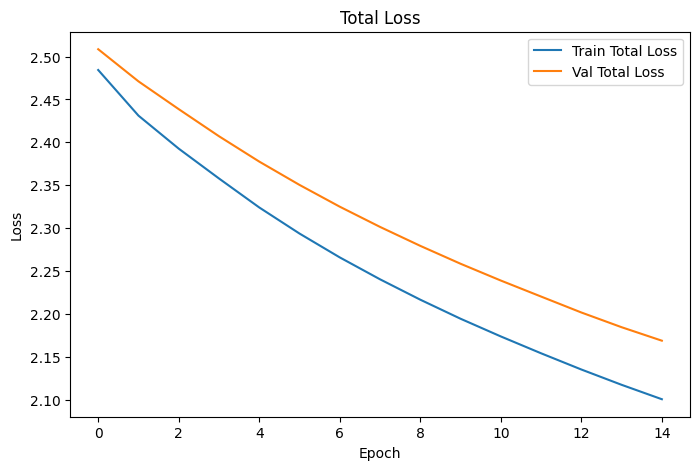

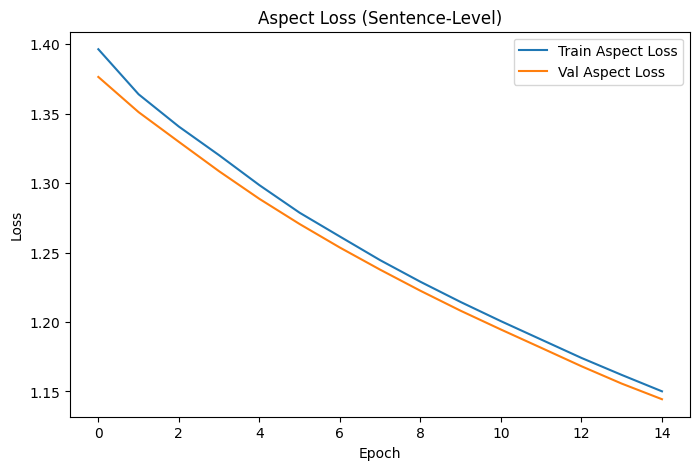

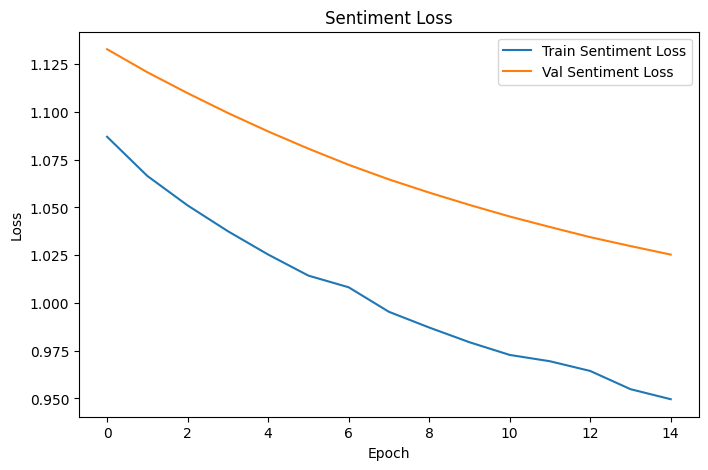

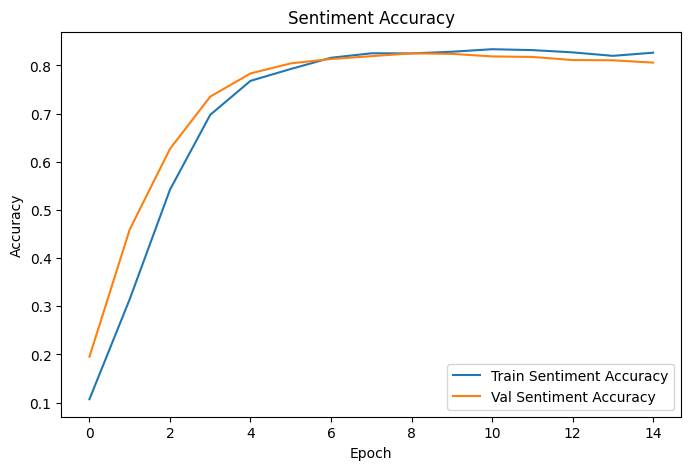

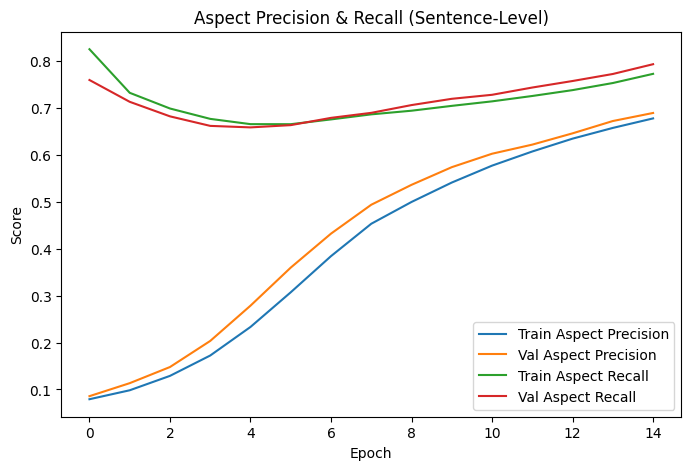

In [ ]:
import matplotlib.pyplot as plt

history_dict = history_tokenLevel.history

# --- Total Loss ---
plt.figure(figsize=(8,5))
plt.plot(history_dict["loss"], label="Train Total Loss")
plt.plot(history_dict["val_loss"], label="Val Total Loss")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- Aspect Loss (sentence-level) ---
plt.figure(figsize=(8,5))
plt.plot(history_dict["sentence_aspect_output_loss"], label="Train Aspect Loss")
plt.plot(history_dict["val_sentence_aspect_output_loss"], label="Val Aspect Loss")
plt.title("Aspect Loss (Sentence-Level)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- Sentiment Loss ---
plt.figure(figsize=(8,5))
plt.plot(history_dict["sentiment_output_loss"], label="Train Sentiment Loss")
plt.plot(history_dict["val_sentiment_output_loss"], label="Val Sentiment Loss")
plt.title("Sentiment Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- Sentiment Accuracy ---
plt.figure(figsize=(8,5))
plt.plot(history_dict["sentiment_output_accuracy"], label="Train Sentiment Accuracy")
plt.plot(history_dict["val_sentiment_output_accuracy"], label="Val Sentiment Accuracy")
plt.title("Sentiment Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# --- Aspect Precision & Recall ---
plt.figure(figsize=(8,5))
plt.plot(history_dict["sentence_aspect_output_precision"], label="Train Aspect Precision")
plt.plot(history_dict["val_sentence_aspect_output_precision"], label="Val Aspect Precision")
plt.plot(history_dict["sentence_aspect_output_recall"], label="Train Aspect Recall")
plt.plot(history_dict["val_sentence_aspect_output_recall"], label="Val Aspect Recall")
plt.title("Aspect Precision & Recall (Sentence-Level)")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.show()


### Evaluation

In [ ]:
# --- Tokenize test texts ---
test_encodings = tokenizer(
    X_test_single,          # list of raw sentences
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='tf'
)

# --- Extract tensors for the model ---
X_test_input_ids = test_encodings["input_ids"]
X_test_attention = test_encodings["attention_mask"]

# --- Aspect labels ---
# Trained with sentence-level aspect labels:
y_test_aspect_sentence = np.max(y_aspect_test_single, axis=1).astype("float32")  # (num_samples, NUM_ASPECTS)

# Sentiment labels (already correct format)
y_test_sent = y_sent_test.astype("int32")


In [ ]:
# Predict on test set
pred_aspect_test, pred_sent_test = model_tokenLevel.predict(
    {
        "input_ids": X_test_input_ids,
        "attention_mask": X_test_attention
    }
)

# --- Aspect predictions (multi-label sigmoid -> threshold) ---
aspect_preds_test = (pred_aspect_test > 0.65).astype(int)

# --- Sentiment predictions (softmax -> class ID) ---
sent_preds_test = np.argmax(pred_sent_test, axis=1)

# --- True labels ---
y_true_aspect_test = y_test_aspect_sentence   # already shape: (N, NUM_ASPECTS)
y_true_sent_test = y_test_sent                # shape: (N,)


59/59 ━━━━━━━━━━━━━━━━━━━━ 50s 853ms/step


=== Aspect Classification Reports (Per Aspect) ===


--- Aspect: Clean ---
              precision    recall  f1-score   support

     Clean=0       0.97      0.98      0.98      1653
     Clean=1       0.87      0.81      0.84       217

    accuracy                           0.96      1870
   macro avg       0.92      0.90      0.91      1870
weighted avg       0.96      0.96      0.96      1870


--- Aspect: Comfort ---
              precision    recall  f1-score   support

   Comfort=0       0.92      1.00      0.96      1716
   Comfort=1       0.74      0.09      0.16       154

    accuracy                           0.92      1870
   macro avg       0.83      0.54      0.56      1870
weighted avg       0.91      0.92      0.89      1870


--- Aspect: Facilities/Amenities ---
                        precision    recall  f1-score   support

Facilities/Amenities=0       0.92      0.95      0.94      1553
Facilities/Amenities=1       0.72      0.62      0.66       317

              

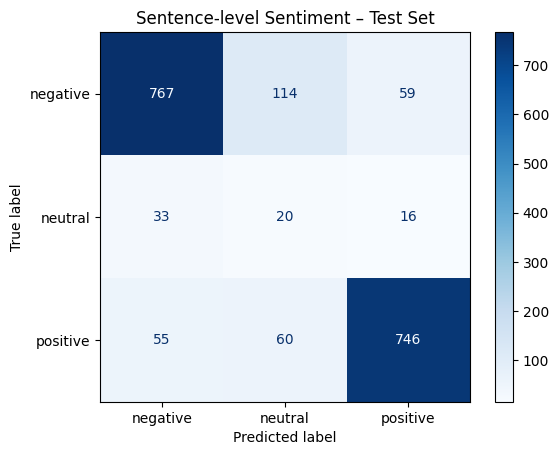


=== Sentiment Classification Report ===
              precision    recall  f1-score   support

    negative       0.90      0.82      0.85       940
     neutral       0.10      0.29      0.15        69
    positive       0.91      0.87      0.89       861

    accuracy                           0.82      1870
   macro avg       0.64      0.66      0.63      1870
weighted avg       0.87      0.82      0.84      1870



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# ASPECT: Multi-label evaluation
# ------------------------------

print("=== Aspect Classification Reports (Per Aspect) ===\n")

for i, asp in enumerate(ASPECT_COLS):
    print(f"\n--- Aspect: {asp} ---")
    print(classification_report(
        y_true_aspect_test[:, i],
        aspect_preds_test[:, i],
        target_names=[f"{asp}=0", f"{asp}=1"],
        zero_division=0
    ))

# ------------------------------
# SENTIMENT
# ------------------------------

print("\n=== Sentiment Confusion Matrix ===")
cm_sent = confusion_matrix(y_true_sent_test, sent_preds_test)

disp = ConfusionMatrixDisplay(cm_sent, display_labels=['negative', 'neutral', 'positive'])
disp.plot(cmap="Blues")
plt.title("Sentence-level Sentiment – Test Set")
plt.show()

print("\n=== Sentiment Classification Report ===")
print(classification_report(
    y_true_sent_test,
    sent_preds_test,
    target_names=['negative', 'neutral', 'positive'],
    zero_division=0
))


In [ ]:
y_true_aspect_test = y_true_aspect_test.astype("int32")
aspect_preds_test = aspect_preds_test.astype("int32")

print(classification_report(
    y_true_aspect_test,
    aspect_preds_test,
    target_names=ASPECT_COLS,
    zero_division=0
))


                      precision    recall  f1-score   support

               Clean       0.87      0.81      0.84       217
             Comfort       0.74      0.09      0.16       154
Facilities/Amenities       0.72      0.62      0.66       317
            Location       0.96      0.86      0.91       516
                 Bar       0.47      0.97      0.64        29
                 Bed       0.90      0.25      0.40        75
             Parking       0.93      0.90      0.92        30
               Noise       0.99      0.73      0.84       153
   Reception-checkin       0.73      0.82      0.77       102
                Lift       0.89      0.80      0.84        30
     Value for money       0.71      0.71      0.71        65
               Wi-Fi       0.89      1.00      0.94        31
             Generic       1.00      0.09      0.17       151

           micro avg       0.85      0.65      0.74      1870
           macro avg       0.83      0.67      0.68      1870
      

In [ ]:
for x, y in ds_train_multi.take(1):
    print(x['input_ids'].shape)                  # (batch_size, MAX_LEN)
    print(y['sentence_aspect_output'].shape)    # (batch_size, NUM_ASPECTS)
    print(y['sentiment_output'].shape)          # (batch_size,)
    print(y['sentence_aspect_output'].dtype)    # float32
    print(y['sentiment_output'].dtype)          # int32


(16, 128)
(16, 128, 13)
(16,)
<dtype: 'float32'>
<dtype: 'int32'>


2025-12-09 19:12:17.616631: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
